# Well Log Uncertainty Quantification
## A Hands-On Probability Lab

> **Context:** Predict **lithofacies and petrophysical states** from well-log measurements.

**Learning Objectives:**
1. How to assign a probability distribution over geological states given log observations.
2. How `random.choices` sampling generates multiple equally-valid geological *realisations* — the foundation of Monte Carlo UQ.
3. How changing the "context" (a different log reading) shifts the distribution, just as *hungry → thirsty* shifted word probabilities.
4. How to quantify uncertainty from the spread of those realisations (P10 / P50 / P90).

**Estimated time:** 35–45 minutes  
**Prerequisites:** Equivalent familiarity with probability distributions and `random.choices`)


## 0 · Imports and Setup

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# Reproducibility — remove or change seed to get different realisations
random.seed(42)
np.random.seed(42)

print("All imports successful. Let's do some petrophysics!")


All imports successful. Let's do some petrophysics!


## 1 · Background: From Words to Rocks

Given a set of **log measurements** at a particular depth (the "prompt"), they assign probabilities to candidate **lithofacies** (rock types) — the "next words":

| Log reading (context) | Candidate lithofacies | Geologist's probability |
|-----------------------|-----------------------|------------------------|
| GR = 120 API (high)   | Shale                 | 0.85 |
|                       | Sandstone             | 0.08 |
|                       | Limestone             | 0.07 |

The log measurements are the **context**. The lithofacies are the **candidate words**. The probability distribution is the **mental model** of the subsurface.

### Key log measurements we will use

| Log | Symbol | Units | What it senses | High value → | Low value → |
|-----|--------|-------|----------------|-------------|-------------|
| Gamma Ray | GR | API | Radioactive clay minerals | Shale | Clean sand/carbonate |
| Bulk Density | RHOB | g/cc | Electron density | Dense rock / low porosity | Porous / light minerals |
| Neutron Porosity | NPHI | v/v | Hydrogen index | Shale / gas | Liquid-filled pores |
| Deep Resistivity | RT | Ω·m | Electrical conductivity | Hydrocarbons / tight rock | Saline water |


---
## Part 1 · Assigning Lithofacies Probabilities (Echo of Activity 1)

### The "prompt": Evaluate a depth interval with the following log readings:

```
Gamma Ray  (GR)  =  35 API      ← Very low: almost no clay
Bulk Density (RHOB) = 2.32 g/cc  ← Moderate-low: suggests porosity
Neutron Porosity (NPHI) = 0.22   ← Moderate: liquid-filled pores
Deep Resistivity (RT) = 48 Ω·m  ← Elevated: not fully brine-saturated
```

The Gamma Ray (35 API) indicates the formation is "clean" (low clay content)
. In a clean formation, when the neutron porosity and limestone-calculated density porosity align so closely (~22% vs ~22.8%), the lithology is interpreted as limestone
. If it were sandstone, these two values would show a significant separation on the log


The candidate lithofacies are listed below. Assign the probabilities. The rules are identical:
1. All probabilities ≥ 0
2. Probabilities must sum to 1.0
3. One probability per candidate

### **1. Lithology: Clean Limestone**
*   **Gamma Ray (GR) = 35 API:** This low value indicates a **"clean" formation** with very little clay or shale content. Pure sandstones and carbonates typically exhibit low radioactivity, whereas shales generally have higher readings.
*   **Density and Neutron Comparison:** By comparing the Bulk Density ($\rho_b$ = 2.32 g/cc) and Neutron Porosity ($\phi_n$ = 0.22), we can deduce the mineralogy.
    *   The matrix density of **limestone** (calcite) is 2.71 g/cc.
    *   Using the porosity equation $\phi_d = (\rho_{ma} - \rho_b) / (\rho_{ma} - \rho_f)$, and assuming a fluid density ($\rho_f$) of 1.0 g/cc for fresh-water filtrate, the calculated density porosity is approximately **22.8%**.
    *   Since the Neutron Porosity (22%) and the calculated Density Porosity (22.8%) are nearly identical, this formation is almost certainly **limestone**. If the lithology were sandstone or dolomite, these two values would typically show a significant separation.

### **2. Porosity: High (22–23%)**
The formation possesses a **total porosity of approximately 22–23%**. This is considered a high-porosity reservoir, which provides significant space for fluids.

### **3. Fluid Content: Likely Hydrocarbons (Oil)**
*   **Deep Resistivity (RT) = 48 Ω·m:** This is a relatively high resistivity reading for a porous formation.
*   **Hydrocarbon Indication:** Hydrocarbons are poor electrical conductors (infinitely resistive), while formation water conducts electricity due to dissolved salts. A formation with ~22% porosity that was 100% water-saturated would typically show much lower resistivity, depending on the water's salinity.
*   **Interpretation:** The combination of high porosity and high resistivity strongly suggests that the pore spaces are occupied by **hydrocarbons**.
*   **Oil vs. Gas:** Because the Neutron Porosity (0.22) and Density Porosity (~0.228) are closely aligned without a significant "crossover" (where the density porosity would be much higher than the neutron porosity), the fluid is more likely to be **oil** rather than low-pressure gas.

### **Summary**
The data describes a **clean, high-porosity (22%) limestone reservoir** that is likely **hydrocarbon-bearing (probably oil)**.

In [2]:
# The candidate lithofacies — analogous to candidate words in GDM Lab 1.1
candidate_facies = [
    "clean_sandstone",     # Not possible: GR makes possible, however RHOB of 2.32 g/cc implies 20% porosity, but a limestone-calibrated NPHI would read ~13-15%, not the given 22% [3, 7].
    "shaly_sandstone",     # Not possible: GR = 35 API indicates a "clean" formation with negligible clay or shale content [8, 9].
    "shale",               # Not possible: GR is far too low (shale typically > 60 API), and Deep Resistivity (48 Ω·m) is too high for characteristic shales [10, 11].
    "limestone",           # Possible: GR makes possible and NPHI (22%) matches calculated Density Porosity (~22.8%) on a limestone scale, the definitive signature for liquid-filled limestone [3, 7].
    "dolomite",            # Not possible: Matrix is too dense (2.87 g/cc); at RHOB=2.32, NPHI and Density Porosity would not align at 22% [1, 2].
    "coal",                # Not possible: RHOB (2.32 g/cc) is far too high; coal is typically < 1.5 g/cc [12, 13].
    "anhydrite",           # Not possible: Anhydrite is a dense mineral (2.98 g/cc) with near-zero porosity, far outside this RHOB/NPHI range [2, 14].
]
# ── YOUR TASK ──────────────────────────────────────────────────────────────
# Assign probabilities that reflect the log context above.
# Hint: GR=35 strongly favours clean lithologies; RT=48 suggests hydrocarbons.

your_mental_model = [
    0.1,   # clean_sandstone
    0.05,   # shaly_sandstone
    0.015,   # shale
    0.8,   # limestone
    0.02,   # dolomite
    0.005,   # coal
    0.01,   # anhydrite
]

# ── VALIDATION (same logic as probabilities.test_probabilities in GDM lab) ──
def test_distribution(candidates, probs, label="distribution"):
    assert len(candidates) == len(probs),         f"Length mismatch: {len(candidates)} candidates but {len(probs)} probabilities"
    assert all(p >= 0 for p in probs),         f"All probabilities must be >= 0. Got: {probs}"
    total = sum(probs)
    assert abs(total - 1.0) < 1e-6,         f"Probabilities must sum to 1.0. Currently sum to {total:.6f}"
    print(f"✅ Valid probability distribution over {len(candidates)} {label}.")
    for c, p in zip(candidates, probs):
        bar = "█" * int(p * 40)
        print(f"  {c:<20s}  {p:.3f}  {bar}")

test_distribution(candidate_facies, your_mental_model, label="lithofacies")


✅ Valid probability distribution over 7 lithofacies.
  clean_sandstone       0.100  ████
  shaly_sandstone       0.050  ██
  shale                 0.015  
  limestone             0.800  ████████████████████████████████
  dolomite              0.020  
  coal                  0.005  
  anhydrite             0.010  


### Sample a single realisation

It now picks a lithofacies interpretation at this depth — weighted by the probabilities.


In [7]:
chosen_facies = random.choices(candidate_facies, weights=your_mental_model, k=1)[0]

print(f"Log context:  GR=35 API | RHOB=2.32 g/cc | NPHI=0.22 | RT=48 Ω·m")
print(f"Interpreted lithofacies: >>> {chosen_facies.upper()} <<<")
print()
print("Run this cell multiple times. Notice that results vary — this IS the uncertainty.")


Log context:  GR=35 API | RHOB=2.32 g/cc | NPHI=0.22 | RT=48 Ω·m
Interpreted lithofacies: >>> LIMESTONE <<<

Run this cell multiple times. Notice that results vary — this IS the uncertainty.


### 🔬 Reflection 1
> Run the sampling cell **10 times**. Note down which facies appear and how often.  
> - Does the sampled facies match your intuition about the log readings?  
> - How does this variability compare to a deterministic interpretation (always picking the single most-probable facies)?  
> - In the GDM lab, changing *hungry → thirsty* shifted the word distribution. What log measurement would most dramatically shift the facies distribution here?


---
## Part 2 · Monte Carlo Sampling: Generating Many Realisations

Running `random.choices` once gives one interpretation. But in subsurface UQ we need **thousands of realisations** to characterise the full uncertainty — this is **Monte Carlo simulation**.

The idea: if we repeat the probabilistic interpretation N times, the *histogram* of results gives us a **posterior distribution** over lithofacies. Its shape tells us how confident the logs are about the rock type.


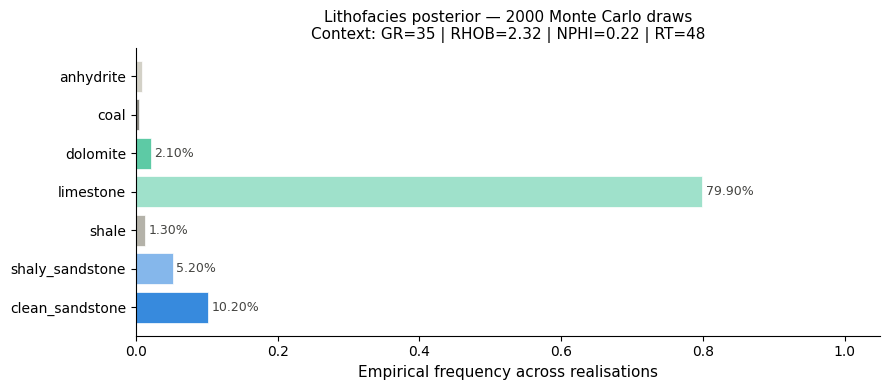

Most probable facies: limestone (79.9%)
Interpretation entropy (uncertainty): 0.772 nats
(Higher entropy = more uncertain interpretation)


In [13]:
N_REALISATIONS = 2000   # number of Monte Carlo draws

# Draw N realisations from your probability distribution
realisations = random.choices(candidate_facies, weights=your_mental_model, k=N_REALISATIONS)

# Count occurrences — equivalent to empirical frequency
counts = Counter(realisations)
freqs = {f: counts.get(f, 0) / N_REALISATIONS for f in candidate_facies}

# ── Plot ──
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#378ADD", "#85B7EB", "#B4B2A9", "#9FE1CB", "#5DCAA5", "#888780", "#D3D1C7"]
bars = ax.barh(candidate_facies, [freqs[f] for f in candidate_facies],
               color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Empirical frequency across realisations", fontsize=11)
ax.set_title(f"Lithofacies posterior — {N_REALISATIONS} Monte Carlo draws\n"
             f"Context: GR=35 | RHOB=2.32 | NPHI=0.22 | RT=48", fontsize=11)
for bar, facies in zip(bars, candidate_facies):
    w = bar.get_width()
    if w > 0.01:
        ax.text(w + 0.005, bar.get_y() + bar.get_height()/2,
                f"{w:.2%}", va="center", fontsize=9, color="#444441")
ax.set_xlim(0, 1.05)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Most probable facies: {max(freqs, key=freqs.get)} ({max(freqs.values()):.1%})")
print(f"Interpretation entropy (uncertainty): "
      f"{-sum(p*np.log(p+1e-12) for p in your_mental_model):.3f} nats")
print("(Higher entropy = more uncertain interpretation)")


### From lithofacies to porosity: propagating uncertainty

Once we have a facies realisation, we can assign a **porosity** to it — each facies has a characteristic porosity range. This propagates the *classification* uncertainty into a *petrophysical* uncertainty.


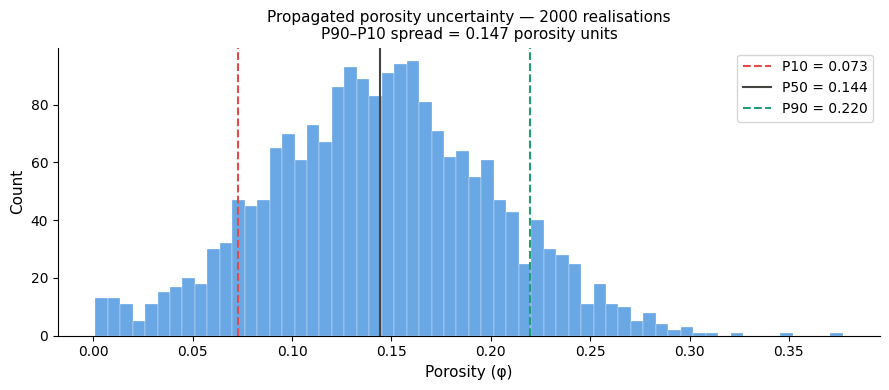

P10 (pessimistic): φ = 0.073
P50 (median):      φ = 0.144
P90 (optimistic):  φ = 0.220
Uncertainty range: 0.147 porosity units


In [14]:
# Characteristic porosity ranges per facies (mean, std) — from analogue databases
POROSITY_PARAMS = {
    "clean_sandstone":  (0.22, 0.04),
    "shaly_sandstone":  (0.16, 0.04),
    "shale":            (0.08, 0.03),
    "limestone":        (0.14, 0.05),
    "dolomite":         (0.10, 0.04),
    "coal":             (0.05, 0.02),
    "anhydrite":        (0.01, 0.005),
}

def sample_porosity(facies):
    mu, sigma = POROSITY_PARAMS[facies]
    phi = np.random.normal(mu, sigma)
    return max(0.001, min(0.5, phi))   # physical bounds

# Full Monte Carlo: facies draw → porosity draw
porosity_samples = []
facies_samples = random.choices(candidate_facies, weights=your_mental_model, k=N_REALISATIONS)
for f in facies_samples:
    porosity_samples.append(sample_porosity(f))

porosity_samples = np.array(porosity_samples)
porosity_samples.sort()

p10 = np.percentile(porosity_samples, 10)
p50 = np.percentile(porosity_samples, 50)
p90 = np.percentile(porosity_samples, 90)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(porosity_samples, bins=60, color="#378ADD", alpha=0.75, edgecolor="white", linewidth=0.3)
ax.axvline(p10, color="#E24B4A", linewidth=1.5, linestyle="--", label=f"P10 = {p10:.3f}")
ax.axvline(p50, color="#444441", linewidth=1.5, linestyle="-",  label=f"P50 = {p50:.3f}")
ax.axvline(p90, color="#1D9E75", linewidth=1.5, linestyle="--", label=f"P90 = {p90:.3f}")
ax.set_xlabel("Porosity (φ)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(f"Propagated porosity uncertainty — {N_REALISATIONS} realisations\n"
             f"P90–P10 spread = {p90-p10:.3f} porosity units", fontsize=11)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"P10 (pessimistic): φ = {p10:.3f}")
print(f"P50 (median):      φ = {p50:.3f}")
print(f"P90 (optimistic):  φ = {p90:.3f}")
print(f"Uncertainty range: {p90 - p10:.3f} porosity units")


---
## Part 3 · The Importance of Context

Changing a prompt from *"hungry"* to *"thirsty"* will shift the probability of *water* versus *food* in the sentence **Shade was hungry so she went to look for ...** . The **same principle** governs log interpretation.

### New "prompt": same depth, now with elevated Gamma Ray

Imagine you log the **adjacent well** and at the equivalent depth you now see:

```
Gamma Ray  (GR)  = 98 API      ← High: significant clay content
Bulk Density (RHOB) = 2.51 g/cc ← Dense: compacted, clay-rich
Neutron Porosity (NPHI) = 0.31  ← High: clay-bound water
Deep Resistivity (RT) = 1.8 Ω·m ← Low: conductive — brine / clay
```

The **candidate lithofacies are identical** — just as Shade's candidate words were the same for both prompts. But the context has changed completely. Reassign new probabilities.


### **1. Shale (Most Possible)**
*   **Gamma Ray Signature:** The high reading of **98 API** is characteristic of radioactive shale beds, which typically exhibit values above 60–100 API due to the concentration of potassium, thorium, and uranium.
*   **Neutron Porosity:** The high **NPHI (31%)** is a definitive indicator of shale. This measurement reflects the high hydrogen content found in the hydroxyl ions of clay minerals and the layer of "bound water" adsorbed on clay particle surfaces.
*   **Resistivity:** The very low **Deep Resistivity (1.8 Ω·m)** confirms a conductive medium. Shales are naturally conductive because of their high clay-mineral content and the presence of saline interstitial water within their fine pore structures.
*   **Density:** A **Bulk Density (RHOB) of 2.51 g/cc** is consistent with a dense, compacted shale.

### **2. Shaly Sandstone**
*   **Consistency:** While a high clay content could produce this GR and NPHI signature, the very low resistivity (1.8 Ω·m) suggests a dominant shale matrix rather than a sand matrix with minor clay. In a sandstone with 31% apparent neutron porosity, one would expect a significant "shale effect" separation from the density porosity.

### **3. Clean Sandstone (Not Possible)**
*   **Gamma Ray Conflict:** Pure sandstones (orthoquartzites) are "clean" formations with very low radioactivity. A reading of 98 API rules out a clean sand interpretation.
*   **Physical Mismatch:** At a density of 2.51 g/cc, a sandstone matrix (2.65 g/cc) would have a true porosity of only **~8.5%**. The recorded NPHI of 31% is physically inconsistent with a clean sandstone at this density.

### **4. Limestone (Not Possible)**
*   **Lithology Conflict:** Pure limestone typically has low GR readings. Furthermore, a bulk density of 2.51 g/cc in a limestone matrix (2.71 g/cc) corresponds to a density porosity of approximately **11.7%**. The massive separation between this and the NPHI (31%) is a classic signature of shale, not limestone.

### **5. Dolomite (Not Possible)**
*   **Density/GR Conflict:** Pure dolomite does not exhibit high radioactivity (98 API). Additionally, dolomite is much denser (matrix density **~2.87 g/cc**); at a bulk density of 2.51 g/cc, the porosity would be **~19.3%**, which still does not align with the 31% NPHI.

### **6. Anhydrite (Least Possible)**
*   **Density Mismatch:** Anhydrite is an exceptionally dense mineral with a bulk density of **2.98 g/cc** and near-zero porosity. It cannot have a density of 2.51 g/cc.

### **7. Coal (Least Possible)**
*   **Density Mismatch:** Coal is very light, with bulk densities typically ranging from **1.2 to 1.5 g/cc**. A reading of 2.51 g/cc effectively rules out coal.

***

**Summary Interpretation:** The data describes a **dense, compacted shale**. The combination of high radioactivity (98 API), high apparent neutron porosity (31%) due to bound water, and very low resistivity (1.8 Ω·m) identifies this as a **clay-rich, conductive formation**, likely serving as a seal for a reservoir.

In [16]:
# Same candidates as before — context (log readings) has changed
candidate_facies_2 = [
    "clean_sandstone",
    "shaly_sandstone",
    "shale",
    "limestone",
    "dolomite",
    "coal",
    "anhydrite",
]

# ── YOUR TASK ──────────────────────────────────────────────────────────────
# Context: GR=98 | RHOB=2.51 | NPHI=0.31 | RT=1.8
# High GR, high NPHI, low RT → strong shale signature.
# Reassign probabilities to reflect this new context.

your_mental_model_2 = [
    0.02,   # clean_sandstone
    0.35,   # shaly_sandstone
    0.6,   # shale
    0.02,   # limestone
    0.008,   # dolomite
    0.0005,   # coal
    0.0015,   # anhydrite
]

test_distribution(candidate_facies_2, your_mental_model_2, label="lithofacies (high-GR context)")


✅ Valid probability distribution over 7 lithofacies (high-GR context).
  clean_sandstone       0.020  
  shaly_sandstone       0.350  ██████████████
  shale                 0.600  ████████████████████████
  limestone             0.020  
  dolomite              0.008  
  coal                  0.001  
  anhydrite             0.002  


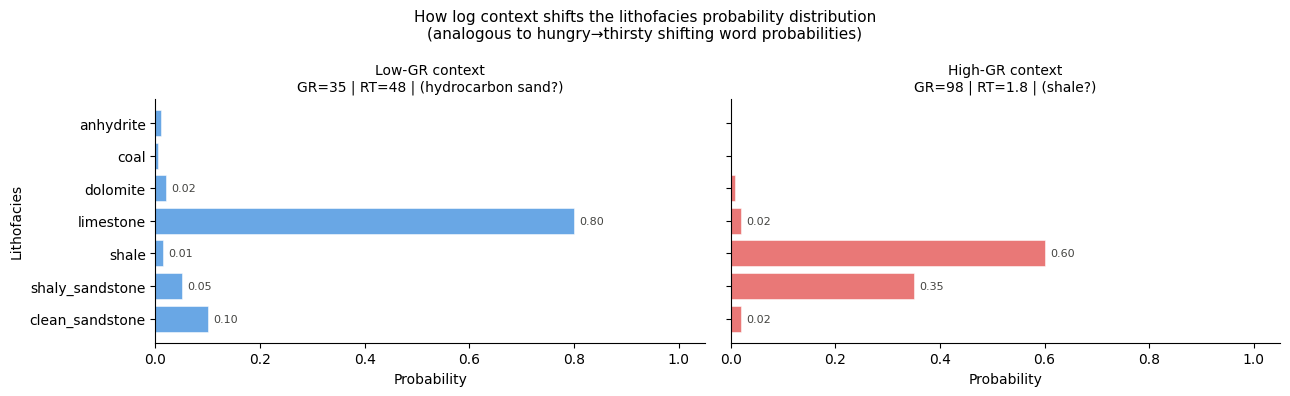

In [17]:
# Side-by-side comparison — low GR vs high GR context
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, model, title, color in zip(
    axes,
    [your_mental_model, your_mental_model_2],
    ["Low-GR context\nGR=35 | RT=48 | (hydrocarbon sand?)",
     "High-GR context\nGR=98 | RT=1.8 | (shale?)"],
    ["#378ADD", "#E24B4A"]
):
    ax.barh(candidate_facies, model, color=color, alpha=0.75, edgecolor="white", linewidth=0.5)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Probability", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    for i, (facies, p) in enumerate(zip(candidate_facies, model)):
        if p > 0.01:
            ax.text(p + 0.01, i, f"{p:.2f}", va="center", fontsize=8, color="#444441")

axes[0].set_ylabel("Lithofacies", fontsize=10)
plt.suptitle("How log context shifts the lithofacies probability distribution\n"
             "(analogous to hungry→thirsty shifting word probabilities)", fontsize=11)
plt.tight_layout()
plt.show()


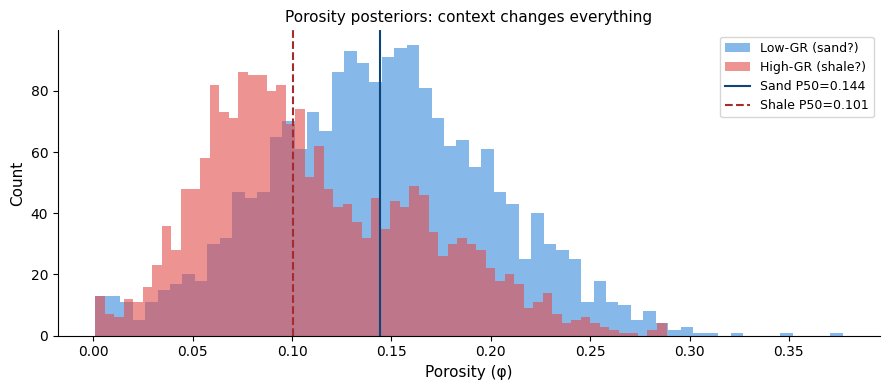

Low-GR context  → P10/P50/P90: 0.073 / 0.144 / 0.220
High-GR context → P10/P50/P90: 0.049 / 0.101 / 0.189


In [18]:
# Monte Carlo for the high-GR context
realisations_2 = random.choices(candidate_facies_2, weights=your_mental_model_2, k=N_REALISATIONS)
porosity_samples_2 = []
for f in realisations_2:
    porosity_samples_2.append(sample_porosity(f))
porosity_samples_2 = np.array(porosity_samples_2)

p10_2 = np.percentile(porosity_samples_2, 10)
p50_2 = np.percentile(porosity_samples_2, 50)
p90_2 = np.percentile(porosity_samples_2, 90)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(porosity_samples,   bins=60, color="#378ADD", alpha=0.6, label="Low-GR (sand?)",  edgecolor="none")
ax.hist(porosity_samples_2, bins=60, color="#E24B4A", alpha=0.6, label="High-GR (shale?)", edgecolor="none")
for p, color, ls, label in [
    (p50,  "#0C447C", "-",  f"Sand P50={p50:.3f}"),
    (p50_2,"#A32D2D", "--", f"Shale P50={p50_2:.3f}"),
]:
    ax.axvline(p, color=color, linewidth=1.5, linestyle=ls, label=label)
ax.set_xlabel("Porosity (φ)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Porosity posteriors: context changes everything", fontsize=11)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Low-GR context  → P10/P50/P90:", f"{p10:.3f} / {p50:.3f} / {p90:.3f}")
print("High-GR context → P10/P50/P90:", f"{p10_2:.3f} / {p50_2:.3f} / {p90_2:.3f}")


### 🔬 Reflection 2
> Compare your two distributions — side by side chart and porosity posteriors.
> - Which single log measurement most strongly shifted your probabilities? Why?
> - In the GDM lab, *context-awareness* was the key property of a good language model. What is the equivalent property for a good petrophysical interpretation model?
> - Notice how the porosity spread (P90–P10) differs between the two contexts. Which context is *more certain*, and why does that make physical sense?


---
## Part 4 · Where Does the Uncertainty Come From?

In the UQ explorer widget we discussed three sources of uncertainty:
- **Measurement uncertainty** — tool noise and borehole environmental effects
- **Model uncertainty** — Archie/transform equation parameters (e.g., cementation exponent *m*)
- **Geological uncertainty** — net-to-gross, spatial variability

Here we implement a simple **variance decomposition** to see which source dominates — a technique central to Sobol sensitivity analysis.


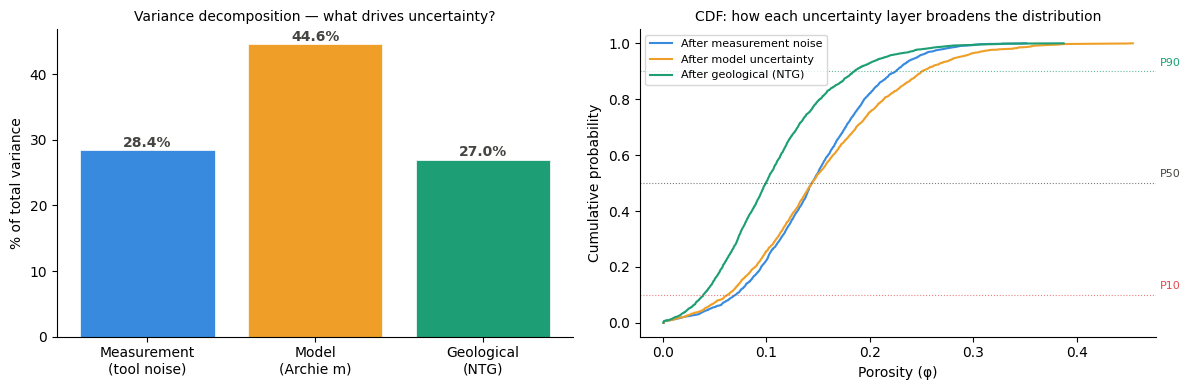

Variance contributions:
  Measurement           : 28.4%
  Model (Archie)        : 44.6%
  Geological (NTG)      : 27.0%

Conclusion: Model uncertainty dominates with 44.6% of total variance.


In [19]:
def full_mc_porosity(facies_probs, n=3000,
                    meas_sigma=0.015, bh_bias=0.0,
                    archie_m_mean=2.0, archie_m_std=0.15,
                    ntg_mean=0.7, ntg_std=0.15):
    """
    Three-layer Monte Carlo porosity estimator.

    Layer 1 — Measurement:  observed_phi = true_phi + N(bh_bias, meas_sigma)
    Layer 2 — Model:        Archie m perturbs the log-derived phi
    Layer 3 — Geological:   NTG scales effective porosity

    Returns arrays for each uncertainty stage.
    """
    # True phi from facies classification uncertainty
    facies_draws = random.choices(candidate_facies, weights=facies_probs, k=n)
    true_phi = np.array([sample_porosity(f) for f in facies_draws])

    # Layer 1: measurement noise
    meas_err = np.random.normal(bh_bias, meas_sigma, n)
    phi_meas = np.clip(true_phi + meas_err, 0.001, 0.6)

    # Layer 2: Archie model uncertainty (cementation exponent m)
    m_samples = np.random.normal(archie_m_mean, archie_m_std, n)
    model_factor = np.clip(
        (phi_meas ** archie_m_mean) / (phi_meas ** m_samples + 1e-10),
        0.5, 2.0
    )
    phi_model = np.clip(phi_meas * model_factor, 0.001, 0.6)

    # Layer 3: geological (net-to-gross)
    ntg_samples = np.clip(np.random.normal(ntg_mean, ntg_std, n), 0.05, 1.0)
    phi_effective = phi_model * ntg_samples

    return phi_meas, phi_model, phi_effective

# Run for the low-GR (sand) context
phi_meas, phi_model, phi_eff = full_mc_porosity(your_mental_model)

var_meas  = np.var(phi_meas)
var_model = np.var(phi_model)
var_geol  = np.var(phi_eff)
var_total = var_meas + var_model + var_geol

labels = ["Measurement\n(tool noise)", "Model\n(Archie m)", "Geological\n(NTG)"]
variances = [var_meas, var_model, var_geol]
contributions = [v / var_total * 100 for v in variances]
colors_bar = ["#378ADD", "#EF9F27", "#1D9E75"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Variance contributions
axes[0].bar(labels, contributions, color=colors_bar, edgecolor="white", linewidth=0.5)
axes[0].set_ylabel("% of total variance", fontsize=10)
axes[0].set_title("Variance decomposition — what drives uncertainty?", fontsize=10)
axes[0].spines[["top", "right"]].set_visible(False)
for i, (l, c) in enumerate(zip(labels, contributions)):
    axes[0].text(i, c + 0.5, f"{c:.1f}%", ha="center", fontsize=10, fontweight="bold", color="#444441")

# Cumulative distributions (CDF) for each stage
for phi_arr, color, lbl in [
    (phi_meas,  "#378ADD", "After measurement noise"),
    (phi_model, "#EF9F27", "After model uncertainty"),
    (phi_eff,   "#1D9E75", "After geological (NTG)"),
]:
    sorted_phi = np.sort(phi_arr)
    cdf = np.arange(1, len(sorted_phi)+1) / len(sorted_phi)
    axes[1].plot(sorted_phi, cdf, color=color, linewidth=1.5, label=lbl)

axes[1].axhline(0.1, color="#E24B4A", linewidth=0.8, linestyle=":", alpha=0.7)
axes[1].axhline(0.5, color="#444441", linewidth=0.8, linestyle=":", alpha=0.7)
axes[1].axhline(0.9, color="#1D9E75", linewidth=0.8, linestyle=":", alpha=0.7)
axes[1].text(0.48, 0.12, "P10", fontsize=8, color="#E24B4A")
axes[1].text(0.48, 0.52, "P50", fontsize=8, color="#444441")
axes[1].text(0.48, 0.92, "P90", fontsize=8, color="#1D9E75")
axes[1].set_xlabel("Porosity (φ)", fontsize=10)
axes[1].set_ylabel("Cumulative probability", fontsize=10)
axes[1].set_title("CDF: how each uncertainty layer broadens the distribution", fontsize=10)
axes[1].legend(fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("Variance contributions:")
for lbl, c in zip(["Measurement", "Model (Archie)", "Geological (NTG)"], contributions):
    print(f"  {lbl:<22s}: {c:.1f}%")
print(f"\nConclusion: {'Geological (NTG)' if contributions[2]==max(contributions) else 'Model' if contributions[1]==max(contributions) else 'Measurement'} "
      f"uncertainty dominates with {max(contributions):.1f}% of total variance.")


---
## Part 5 · Sequential Prediction Along a Depth Column

A well log is a **depth series** — exactly analogous to a *token sequence* in language modelling. Just as a language model predicts word-by-word conditioned on preceding context, a probabilistic log interpreter assigns distributions depth-by-depth.

Here we simulate a small depth column with three distinct zones and propagate uncertainty through each.


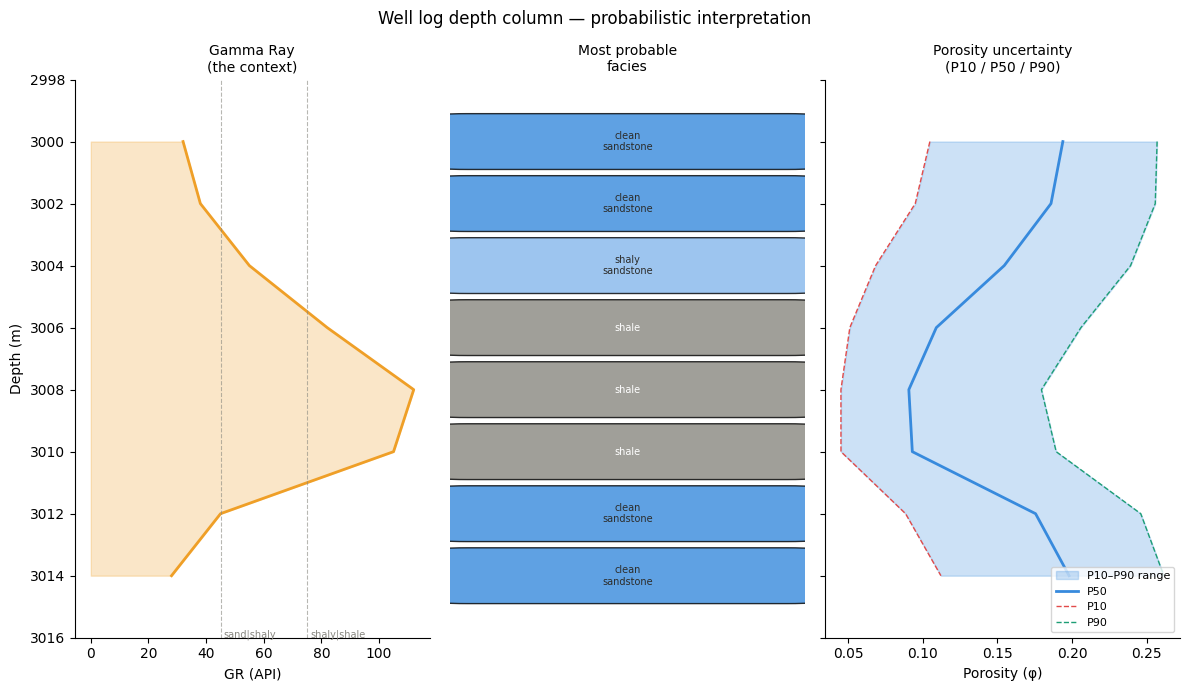

Depth column summary:
 Depth      GR    P10φ    P50φ    P90φ  Dominant facies
-----------------------------------------------------------------
  3000      32   0.105   0.194   0.257  clean_sandstone
  3002      38   0.095   0.186   0.256  clean_sandstone
  3004      55   0.068   0.155   0.239  shaly_sandstone
  3006      82   0.051   0.109   0.206  shale
  3008     112   0.045   0.091   0.180  shale
  3010     105   0.045   0.093   0.189  shale
  3012      45   0.089   0.176   0.246  clean_sandstone
  3014      28   0.112   0.198   0.262  clean_sandstone


In [20]:
# Define a synthetic depth column: 3 geological zones
# Each depth has a GR value (the "context") → drives lithofacies distribution

depth_column = {
    # depth_m : (GR_API, description)
    3000: (32,  "Very clean sand — likely reservoir"),
    3002: (38,  "Clean sand"),
    3004: (55,  "Slightly shaly sand"),
    3006: (82,  "Shaly — transition to seal"),
    3008: (112, "Shale — caprock"),
    3010: (105, "Shale"),
    3012: (45,  "Clean sand — deeper reservoir?"),
    3014: (28,  "Very clean sand"),
}

def gr_to_distribution(gr):
    """
    Map GR reading to a facies probability distribution.
    This is the 'context-aware' step — equivalent to the LM reading the prompt.

    GR < 45    → predominantly clean sand
    45-70      → mixed shaly sand
    > 70       → predominantly shale
    """
    if gr < 45:
        t = max(0, (45 - gr) / 45)          # 0→1 as GR drops to 0
        p_clean = 0.15 + 0.75 * t
        p_shaly = 0.20 - 0.10 * t
        p_shale = max(0.0, 0.05 - 0.03 * t)
        p_lime  = max(0.0, 0.05)
        total   = p_clean + p_shaly + p_shale + p_lime
        return [p_clean/total, p_shaly/total, p_shale/total, p_lime/total, 0.0, 0.0, 0.0]
    elif gr < 75:
        t = (gr - 45) / 30                   # 0→1 as GR goes 45→75
        p_clean = max(0.02, 0.40 - 0.35 * t)
        p_shaly = 0.35 + 0.10 * t
        p_shale = 0.15 + 0.30 * t
        p_lime  = 0.05
        total   = p_clean + p_shaly + p_shale + p_lime
        return [p_clean/total, p_shaly/total, p_shale/total, p_lime/total, 0.0, 0.0, 0.0]
    else:
        t = min(1.0, (gr - 75) / 60)        # 0→1 as GR goes 75→135
        p_shale = 0.50 + 0.45 * t
        p_shaly = max(0.02, 0.35 - 0.30 * t)
        p_clean = max(0.01, 0.10 - 0.09 * t)
        p_lime  = 0.03
        total   = p_shale + p_shaly + p_clean + p_lime
        return [p_clean/total, p_shaly/total, p_shale/total, p_lime/total, 0.0, 0.0, 0.0]

# Run MC for every depth
N_DEPTH = 1000
results = {}

for depth, (gr, desc) in depth_column.items():
    probs = gr_to_distribution(gr)
    facies_draws = random.choices(candidate_facies, weights=probs, k=N_DEPTH)
    phi_arr = np.array([sample_porosity(f) for f in facies_draws])
    results[depth] = {
        "gr": gr, "desc": desc, "probs": probs,
        "p10": np.percentile(phi_arr, 10),
        "p50": np.percentile(phi_arr, 50),
        "p90": np.percentile(phi_arr, 90),
        "dominant_facies": max(zip(probs, candidate_facies))[1],
    }

# ── Plot depth column ────────────────────────────────────────────────────────
depths  = sorted(results.keys())
grs     = [results[d]["gr"]  for d in depths]
p10s    = [results[d]["p10"] for d in depths]
p50s    = [results[d]["p50"] for d in depths]
p90s    = [results[d]["p90"] for d in depths]

fig, axes = plt.subplots(1, 3, figsize=(12, 7), sharey=True)
fig.suptitle("Well log depth column — probabilistic interpretation", fontsize=12)

# Track 1: GR log
axes[0].plot(grs, depths, color="#EF9F27", linewidth=2)
axes[0].fill_betweenx(depths, 0, grs, alpha=0.25, color="#EF9F27")
axes[0].set_xlabel("GR (API)", fontsize=10)
axes[0].set_title("Gamma Ray\n(the context)", fontsize=10)
axes[0].invert_yaxis()
axes[0].set_ylabel("Depth (m)", fontsize=10)
axes[0].axvline(45,  color="#888780", linewidth=0.8, linestyle="--", alpha=0.6)
axes[0].axvline(75,  color="#888780", linewidth=0.8, linestyle="--", alpha=0.6)
axes[0].text(46, max(depths)+2, "sand|shaly", fontsize=7, color="#888780")
axes[0].text(76, max(depths)+2, "shaly|shale", fontsize=7, color="#888780")
axes[0].spines[["top", "right"]].set_visible(False)

# Track 2: dominant facies label
facies_colors = {
    "clean_sandstone": "#378ADD", "shaly_sandstone": "#85B7EB",
    "shale": "#888780", "limestone": "#9FE1CB",
    "dolomite": "#5DCAA5", "coal": "#2C2C2A", "anhydrite": "#D3D1C7",
}
for d in depths:
    fc = results[d]["dominant_facies"]
    rect = mpatches.FancyBboxPatch(
        (0.05, d - 0.8), 0.9, 1.6,
        boxstyle="round,pad=0.1",
        facecolor=facies_colors.get(fc, "#cccccc"), alpha=0.8
    )
    axes[1].add_patch(rect)
    axes[1].text(0.5, d, fc.replace("_", "\n"), ha="center", va="center",
                 fontsize=7, color="white" if fc in ["shale", "coal"] else "#2C2C2A")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(min(depths)-2, max(depths)+2)
axes[1].set_title("Most probable\nfacies", fontsize=10)
axes[1].set_xlabel("", fontsize=10)
axes[1].axis("off")
axes[1].invert_yaxis()

# Track 3: P10/P50/P90 porosity
axes[2].fill_betweenx(depths, p10s, p90s, alpha=0.25, color="#378ADD", label="P10–P90 range")
axes[2].plot(p50s, depths, color="#378ADD", linewidth=2, label="P50")
axes[2].plot(p10s, depths, color="#E24B4A", linewidth=1, linestyle="--", label="P10")
axes[2].plot(p90s, depths, color="#1D9E75", linewidth=1, linestyle="--", label="P90")
axes[2].set_xlabel("Porosity (φ)", fontsize=10)
axes[2].set_title("Porosity uncertainty\n(P10 / P50 / P90)", fontsize=10)
axes[2].legend(fontsize=8, loc="lower right")
axes[2].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("Depth column summary:")
print(f"{'Depth':>6}  {'GR':>6}  {'P10φ':>6}  {'P50φ':>6}  {'P90φ':>6}  Dominant facies")
print("-" * 65)
for d in depths:
    r = results[d]
    print(f"{d:>6}  {r['gr']:>6}  {r['p10']:>6.3f}  {r['p50']:>6.3f}  {r['p90']:>6.3f}  {r['dominant_facies']}")


### 🔬 Reflection 3
> Look at the depth column plot (Track 3).
> - At which depths is the porosity uncertainty *widest* (large P90–P10 gap)? What log feature explains this?
> - In language modelling, ambiguous context (e.g. "she went looking for…") produces a *flatter* probability distribution. What is the geological equivalent of an "ambiguous context"?
> - If you had an additional log (e.g. deep resistivity), how would you expect the uncertainty bands to change?


---
## Part 6 · Extension — Temperature and Sampling Strategy

In language models, **temperature** controls how peaked or flat the sampling distribution is:
- **Low temperature** (T→0): always picks the most probable token (deterministic / greedy)
- **High temperature** (T→∞): samples uniformly regardless of probabilities (maximum entropy)

The same concept applies to geological interpretation. A **low-temperature** interpreter always assigns the lithofacies to the single most-probable class — this is equivalent to a deterministic cutoff interpretation. A **high-temperature** interpreter remains open to unlikely scenarios, which is important when data quality is poor.


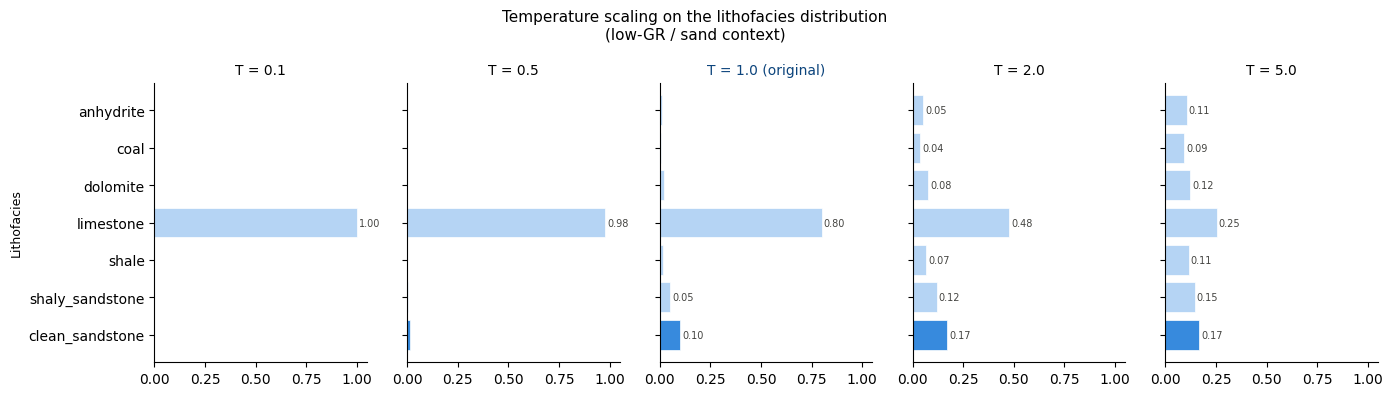

Entropy at each temperature (higher = more uncertain):
  T= 0.1: entropy = 0.000 nats  
  T= 0.5: entropy = 0.114 nats  
  T= 1.0: entropy = 0.772 nats  ██████
  T= 2.0: entropy = 1.562 nats  ████████████
  T= 5.0: entropy = 1.889 nats  ███████████████


In [21]:
def apply_temperature(probs, temperature=1.0):
    """
    Apply temperature scaling to a probability distribution.
    Equivalent to the softmax temperature in language models.

    T < 1 → sharper (more confident)
    T = 1 → unchanged
    T > 1 → flatter (more uncertain)
    """
    probs = np.array(probs, dtype=float) + 1e-12
    log_probs = np.log(probs) / temperature
    log_probs -= log_probs.max()   # numerical stability
    scaled = np.exp(log_probs)
    return (scaled / scaled.sum()).tolist()

# Use the low-GR (sand) distribution from Part 1
base_probs = your_mental_model
temperatures = [0.1, 0.5, 1.0, 2.0, 5.0]

fig, axes = plt.subplots(1, len(temperatures), figsize=(14, 4), sharey=True)
fig.suptitle("Temperature scaling on the lithofacies distribution\n"
             "(low-GR / sand context)", fontsize=11)

for ax, T in zip(axes, temperatures):
    scaled = apply_temperature(base_probs, T)
    colors_t = ["#378ADD" if f == "clean_sandstone" else "#B5D4F4" for f in candidate_facies]
    ax.barh(candidate_facies, scaled, color=colors_t, edgecolor="white", linewidth=0.5)
    ax.set_xlim(0, 1.05)
    ax.set_title(f"T = {T}", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    if T == 1.0:
        ax.set_title(f"T = {T} (original)", fontsize=10, color="#0C447C")
    for i, (facies, p) in enumerate(zip(candidate_facies, scaled)):
        if p > 0.03:
            ax.text(p + 0.01, i, f"{p:.2f}", va="center", fontsize=7, color="#444441")

axes[0].set_ylabel("Lithofacies", fontsize=9)
plt.tight_layout()
plt.show()

print("Entropy at each temperature (higher = more uncertain):")
for T in temperatures:
    scaled = apply_temperature(base_probs, T)
    H = -sum(p * np.log(p + 1e-12) for p in scaled)
    bar = "█" * int(H * 8)
    print(f"  T={T:>4.1f}: entropy = {H:.3f} nats  {bar}")


In [22]:
# Extension exercise: what temperature best matches your uncertainty about this interval?
# Consider: if you had very poor-quality logs (noisy, washed-out borehole),
# should you use a higher or lower temperature? Why?

YOUR_TEMPERATURE = 1.0   # ← change this

scaled_probs = apply_temperature(your_mental_model, YOUR_TEMPERATURE)

# Sample porosity realisations at your chosen temperature
facies_t = random.choices(candidate_facies, weights=scaled_probs, k=N_REALISATIONS)
phi_t = np.array([sample_porosity(f) for f in facies_t])

print(f"At T={YOUR_TEMPERATURE}:")
print(f"  P10 porosity: {np.percentile(phi_t, 10):.3f}")
print(f"  P50 porosity: {np.percentile(phi_t, 50):.3f}")
print(f"  P90 porosity: {np.percentile(phi_t, 90):.3f}")
print(f"  Spread (P90-P10): {np.percentile(phi_t, 90) - np.percentile(phi_t, 10):.3f}")
print()
print("Try T=0.1 (confident interpreter) vs T=5.0 (uncertain interpreter).")
print("How does the spread change?")


At T=1.0:
  P10 porosity: 0.075
  P50 porosity: 0.148
  P90 porosity: 0.220
  Spread (P90-P10): 0.145

Try T=0.1 (confident interpreter) vs T=5.0 (uncertain interpreter).
How does the spread change?


---
## Summary

This notebook transferred every concept from **GDM Lab 1.1** into well log uncertainty quantification:

| GDM Lab 1.1 concept | This notebook's petrophysical equivalent |
|---------------------|------------------------------------------|
| Prompt / sentence context | Log measurements at a depth (GR, RHOB, NPHI, RT) |
| Candidate words | Candidate lithofacies (sandstone, shale, …) |
| Probability distribution (mental model) | Facies posterior given log readings |
| `random.choices` sampling | Single geological realisation |
| Running the cell 10 times | Monte Carlo simulation (N=2000) |
| Hungry → thirsty context shift | Low GR → high GR context shift |
| Temperature scaling | Confidence in log quality / data reliability |
| Sentence continuation | Porosity / saturation estimate |

### Key petrophysical insights

1. **Uncertainty is not ignorance — it is information.** A wide P10–P90 range tells you exactly *how much* data you need to collect before making a drilling decision.
2. **Geological uncertainty dominates.** Net-to-gross variability almost always contributes more variance than tool precision — investing in more wells beats investing in better tools.
3. **Context-awareness is non-negotiable.** A GR=35 interval and a GR=98 interval require completely different probability distributions, even with the same candidate facies.
4. **Temperature ↔ data quality.** Poor-quality logs (washed-out boreholes, tool malfunctions) should map to *higher* temperature — widening the distribution to reflect genuine ignorance.

### Next steps

- **Lab 1.2 direction:** Replace your hand-coded `gr_to_distribution` function with a trained classifier (logistic regression, random forest, or neural net) that *learns* the mapping from logs to facies probabilities from labelled core data.
- **Sobol sensitivity analysis:** Compute proper first- and total-order sensitivity indices to replace the simple variance decomposition in Part 4.
- **Depth-series modelling:** Apply a Hidden Markov Model (HMM) or recurrent architecture so the facies at depth d conditions on the interpreted facies at d−1, incorporating geological sequence constraints.


---
## Reference Solutions

Only consult these after genuinely attempting the activities. Type solutions manually rather than copy-pasting — this builds the muscle memory.

### Part 1 — Low-GR (sand) context

```python
your_mental_model = [0.70, 0.15, 0.02, 0.08, 0.02, 0.01, 0.02]
# clean_sandstone  shaly_sand  shale  limestone  dolomite  coal  anhydrite
# Reasoning: GR=35 → very low clay → clean sand dominant
#            RT=48 → elevated → supports hydrocarbon-bearing sand
```

### Part 3 — High-GR (shale) context

```python
your_mental_model_2 = [0.02, 0.12, 0.80, 0.03, 0.01, 0.01, 0.01]
# clean_sandstone  shaly_sand  shale  limestone  dolomite  coal  anhydrite
# Reasoning: GR=98 → high clay → shale dominant
#            RT=1.8 → low resistivity → conductive → brine-saturated clay
```

### Part 6 — Temperature intuition

```
T < 1  →  sharper posterior → use when logs are clean, high-confidence readings
T = 1  →  your raw mental model unchanged
T > 1  →  flatter posterior → use when logs are noisy, washed-out, or tool malfunction
```


---
## References

1. Eldan, R. & Li, Y. (2023). *TinyStories: How Small Can Language Models Be and Still Speak Coherent English?* arXiv:2305.07759.
2. Archie, G.E. (1942). *The electrical resistivity log as an aid in determining some reservoir characteristics.* Trans. AIME, 146(1), 54–62.
3. Saltelli, A. et al. (2008). *Global Sensitivity Analysis: The Primer.* Wiley.
4. Tarantola, A. (2005). *Inverse Problem Theory and Methods for Model Parameter Estimation.* SIAM.
5. Doyen, P. (2007). *Seismic Reservoir Characterization: An Earth Modelling Perspective.* EAGE Publications.
